Tausif Tamim

EID444: Molecular Modelling and Simulation

Professor Sharma

Final Project Main Notebook

## Importing Packages and Global

In [2]:
from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
import mdtraj as md

In [3]:
platform = Platform.getPlatformByName('OpenCL') #GPU Supported

In [4]:
import nglview #Main way of visualizing simulations using large structures such as proteins.
import MDAnalysis as mda
import mdtraj as md

In [5]:
import warnings
warnings.filterwarnings("ignore")

# Goals:

![Goals](Images/goals.png)

# PDB Files:

What are PDB files?

- Stores the three-dimensional (3D) structural information of proteins and other biomolecules.

In [51]:
AmyloidBeta = PDBFile('PDB Files/AmyloidBetaModel.pdb')
u = mda.Universe('PDB Files/AmyloidBetaModel.pdb')
view = nglview.show_mdanalysis(u)
#AmyloidBetaVacVis.add_ball_and_stick()
view.center()
view.gui_style = None
view

NGLWidget()

## Using Packmol:

Manipulate PDB files and Create Solvent Boxes

In this live demonstration, we will be using the package called Packmol. Packmol is a old (2009), yet powerful tool that allows us to create custom boxes for simulation. The package can be found here: https://m3g.github.io/packmol/

Method:

1. Molecules are placed randomly inside region.

2. Defines a "merit" function that represents the "quality" of a molecular arrangement:

![Merit Function](Images/meritfxn.png)

___________________________________________

First Term: Penalizes violations of the minimum distance requirement.

- dtol is the minimum distance tolerance
- ‖pij − pi′j′ ‖ is the Euclidean distance between atoms

Second Term: Penalizes violations of geometrical constraints.

___________________________________________

The merit function vanishes as objectives are fulfilled. This means that molecules are separated and rotations are adequate. This is done usingGENCAN - Optimization Algorithm (GENeralized Constrained ANalysis). This is parallel, reducing the time considerably.

# Finding Solvation Energy:

**Why is finding solvation energy of a protein important?**

When purifying proteins, we often have to deal with proteins that that are insoluble, meaning they do not like to be soluble in solvents when we want to purify alot of them.

Recent data has shown that during the elution step of protein purification, certain **small molecules have the ability to increase the solubility** of proteins in the solvent.

_____________________________________________

**Why Amyloid Beta?**

Not really any particular reason, but since it is a small protein, it is a good start for beginners and easier to visualize in systems.

The good answer: Solubility plays a pathological role in Alzheimer's disease. Low solubility promotes amyloid plaques, a major indicator. Some drugs (solanezumab) are created to increase the solubility of AB.

___________________________________________

While there are many calculation methods, we are going to look at the simplest one:

![Solvation Energy](Images/solvationeqn.png)

Other ways include alchemical methods where protein is gradually moved towards solvent, and a similar formula but including gibbs energy. These methods will take considerably longer, even with a baller gpu.

# Basic Simulation With No Solvent

## Simulation in Vacuum:

### Forcefields:

In [45]:
forcefield = ForceField('amber14-all.xml', 'amber14/tip3pfb.xml') #Defines the main forcefields!

What is a forcefield?

- A set of equations and parameters that describe the interactions between atoms and molecules. Some of which we have learned!
- Amber14 is generally used for standard proteins and is the most common.
- Tip3 is a common forcefield for water.

### Setting up Simulation System:

In [46]:
modeller = Modeller(AmyloidBeta.topology, AmyloidBeta.positions)
residues = modeller.addHydrogens(forcefield)

The modeller class is used in OpenMM to modify molecules on the fly. It takes the topology and the positions from the PDB file saved. 


This modeller usage can include adding hydrogens such as done above, remove hydrogens, and even add basic ions.

In [47]:
system = forcefield.createSystem(modeller.topology, nonbondedCutoff=0.3*nanometer, constraints=HBonds)

size = 10.0 * nanometer
system.setDefaultPeriodicBoxVectors(
    Vec3(size, 0, 0),
    Vec3(0, size, 0),
    Vec3(0, 0, size))

integrator = LangevinMiddleIntegrator(275*kelvin, 1/picosecond, 0.002*picoseconds)
simulation = Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)

**System conditions:**

- Takes the modeller topology of the PDB file.
- PME method: Particle Mesh-Ewald - Used to find electrostatic interactions in long-range. NOT ADDED HERE BECAUSE VACUUM.
- 0.3 nm of resolution cutoff distance.
- Make all Hbonds rigid, not harmonic.
_______________________________________________

**System Integrator:**

- LangevinMiddleIntegrator is akin to a heat bath with constant T.
- Sets temperature to 275K, Friction Coeff. to inverse picoseconds, and finally the integration steps.

______________________________________

**Simulation Object:**

The main bread and butter of OpenMM simulation. It takes the topology of the PDB file, the system constraints devised prior, and the system integrator. With this, we can start actually running the simulation.

### Running the Simulation:

In [48]:
simulation.minimizeEnergy()

**OpenMM minimizes energy using the L-BFGS algorithm, where it finds the local minimum. It is a qusai-Newton method that only relies on the gradient and the function itself.**

In [49]:
simulation.reporters.append(PDBReporter('Data/AmyloidBetaVac.pdb', 500))
simulation.reporters.append(StateDataReporter(stdout, 500, potentialEnergy=True, temperature=True, volume=True, density=True))
simulation.reporters.append(StateDataReporter('Data/AmyloidBetaVac.txt', 100, step=True, potentialEnergy=True, temperature=True, volume=True, density=True))

**Reporters are an important component of record keeping. It is convenient because you can just tell it what to include and it will auto include it. You can even give live output of data incase you want to see if the simulation is blown up or not!**

In [50]:
print("Running NVT")
simulation.step(10000)

Running NVT
#"Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)","Density (g/mL)"
-1668.0909638404846,170.63908472605357,1000.0,0.007490864428084205
-1316.9260251522064,232.46500506160177,1000.0,0.007490864428084205
-1185.8522481918335,259.5701796356446,1000.0,0.007490864428084205
-1040.1747570037842,272.427928154115,1000.0,0.007490864428084205
-1113.924619436264,287.3813841864636,1000.0,0.007490864428084205
-1095.665738582611,290.77894544118203,1000.0,0.007490864428084205
-1131.280568599701,287.88024761225705,1000.0,0.007490864428084205
-1241.4921550750732,294.620877137884,1000.0,0.007490864428084205
-1376.934449672699,273.6562825353628,1000.0,0.007490864428084205
-1144.3425374031067,258.74431568371995,1000.0,0.007490864428084205
-1242.5577745437622,277.31377325181853,1000.0,0.007490864428084205
-1282.0971348285675,287.3378658570632,1000.0,0.007490864428084205
-1276.277279138565,260.8276892153465,1000.0,0.007490864428084205
-1379.691745519638,282.77771396434537,1000.0,0

**Remember what NVT means?**

We are using NVT here and NPT elsewhere because this is in vacuum. Not really any pressure in a perfect vacuum.

In [167]:
u = mda.Universe('SavedData/AmyloidBetaVac.pdb')
view = nglview.show_mdanalysis(u)
view.center()
#view.gui_style = 'NGL'
view.add_representation('licorice',selection="water")
view

NGLWidget(max_frame=19)

Now that the data has been recorded, lets find the solvation energy in water in the next steps.

## Just Solvent:

In [54]:
water = PDBFile("PDB Files/water.pdb")

forcefield = ForceField('amber14-all.xml', 'amber14/tip3pfb.xml')
modeller = Modeller(water.topology, water.positions)
modeller.addSolvent(forcefield, padding=5.0*nanometer)

In [55]:
system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=0.3*nanometer, constraints=HBonds)

size = 10.0 * nanometer ##This is important! If we do not have the right box size, there will be no forces at play!
system.setDefaultPeriodicBoxVectors(
    Vec3(size, 0, 0),
    Vec3(0, size, 0),
   Vec3(0, 0, size))

integrator = LangevinMiddleIntegrator(275*kelvin, 1/picosecond, 0.002*picoseconds)
simulation = Simulation(modeller.topology, system, integrator, platform)
simulation.context.setPositions(modeller.positions)

In [56]:
simulation.minimizeEnergy()

simulation.reporters.append(PDBReporter('Data/BulkWater.pdb', 500))
simulation.reporters.append(StateDataReporter(stdout, 500, potentialEnergy=True, temperature=True, volume=True, density=True))
simulation.reporters.append(StateDataReporter('Data/BulkWater.txt', 100, step=True, potentialEnergy=True, temperature=True, volume=True, density=True))

system.addForce(MonteCarloBarostat(1*bar, 275*kelvin))
simulation.context.reinitialize(preserveState=True)

print("Running NPT")
simulation.step(10000)

Running NPT
#"Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)","Density (g/mL)"
-1721573.9308539927,214.25536195127492,1010.9748487174518,0.9751516041710089
-1692256.0386663936,256.8764207424334,1037.0392958726745,0.950642612509456
-1679076.6201697849,270.29575376692134,1052.461103601383,0.9367127603385103
-1676112.0832261294,274.03643924221507,1061.570353419522,0.9286749034840149
-1677688.4892922752,275.5629412312402,1070.0635414291185,0.9213039294719955
-1678351.7156360522,277.59487279830535,1072.154118726032,0.9195074927052366
-1681666.8238551505,277.3143827834647,1075.003206329422,0.9170705163471512
-1682373.723937206,277.3923412836409,1079.0137089763534,0.9136619278346642
-1682147.4184729122,277.44234662590696,1081.118398158744,0.911883237934325
-1684414.2139232643,276.1768017037017,1085.4936220403943,0.9082077733909337
-1687969.5571894608,275.14655150363564,1083.2404348847635,0.9100968850080292
-1689537.513251461,275.43635869256343,1082.220914985,0.91095425328850

In [168]:
u = mda.Universe('SavedData/BulkWater.pdb')
view = nglview.show_mdanalysis(u)
view.center()
#view.gui_style = 'NGL'
view.add_representation('licorice',selection="water")
view

NGLWidget(max_frame=19)

## Amyloid Beta in Water Solvent:

In [59]:
#Already added Amyloid Beta Model!

modeller = Modeller(AmyloidBeta.topology, AmyloidBeta.positions)
residues = modeller.addHydrogens(forcefield)
modeller.addSolvent(forcefield, padding=5.0*nanometer)

In [92]:
system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=0.3*nanometer, constraints=HBonds)

size = 10.0 * nanometer ##This is important! If we do not have the right box size, its going to explode!
system.setDefaultPeriodicBoxVectors(
    Vec3(size, 0, 0),
    Vec3(0, size, 0),
    Vec3(0, 0, size))

integrator = LangevinMiddleIntegrator(275*kelvin, 1/picosecond, 0.002*picoseconds)
simulation = Simulation(modeller.topology, system, integrator, platform)
simulation.context.setPositions(modeller.positions)

In [61]:
simulation.minimizeEnergy()

simulation.reporters.append(PDBReporter('Data/AmyloidBetainWaterSolvent.pdb', 500))
simulation.reporters.append(StateDataReporter(stdout, 500, potentialEnergy=True, temperature=True, volume=True, density=True))
simulation.reporters.append(StateDataReporter('Data/AmyloidBetainWaterSolvent.txt', 100, step=True, potentialEnergy=True, temperature=True, volume=True, density=True))

system.addForce(MonteCarloBarostat(1*bar, 275*kelvin))
simulation.context.reinitialize(preserveState=True)

print("Running NPT")
simulation.step(10000)

Running NPT
#"Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)","Density (g/mL)"
-1734114.1157968156,190.4908944811768,983.2001486606898,0.9975639553034454
-1690415.2654721327,243.87154472021152,1011.6382935317235,0.9695214538872501
-1669490.9360323586,263.84242183238115,1036.6939093358815,0.9460893136540263
-1664438.9364510588,272.4914757416391,1045.021607913077,0.9385499990871717
-1662424.5627421215,275.80617988937456,1053.665172862822,0.9308507620955464
-1659862.8141871504,276.2221330097638,1062.5635997159422,0.9230553629120125
-1662853.0376424417,277.0343180572739,1068.7627503694982,0.9177013596458188
-1663228.076449383,277.4002593134166,1075.933994357475,0.9115847573331942
-1665052.54554509,278.38037466895844,1076.368443206885,0.9112168192433492
-1666175.0006343052,277.3653960532945,1074.4915054548874,0.9128085463436664
-1667835.4105744362,275.59496488085057,1076.4633100541682,0.9111365152831254
-1671117.363809336,277.05346840072826,1075.832279547374,0.911670943323

In [169]:
u = mda.Universe('SavedData/AmyloidBetainWaterSolvent.pdb', gui=True)
view = nglview.show_mdanalysis(u)
view.center()
view.add_ball_and_stick()
#view.gui_style = 'NGL'
view

NGLWidget(max_frame=19)

## Analysis:

In [175]:
import numpy as np
import matplotlib.pyplot as plt
from pymbar.timeseries import detect_equilibration

vacuumdata = np.loadtxt("SavedData/AmyloidBetaVac.txt", delimiter=',')
bulksolvdata = np.loadtxt("SavedData/BulkWater.txt", delimiter=',')
ABinsolvdata = np.loadtxt("SavedData/AmyloidBetainWaterSolvent.txt", delimiter=',')

step_vac = vacuumdata[:, 0] * 0.002
step_bulk = bulksolvdata[:, 0] * 0.002
step_AB = ABinsolvdata[:, 0] * 0.002

### Potential Energy Data:

The Equilibration time for Bulk Solvent is 85 ps and for Amyloid Beta in Water is 80 ps.


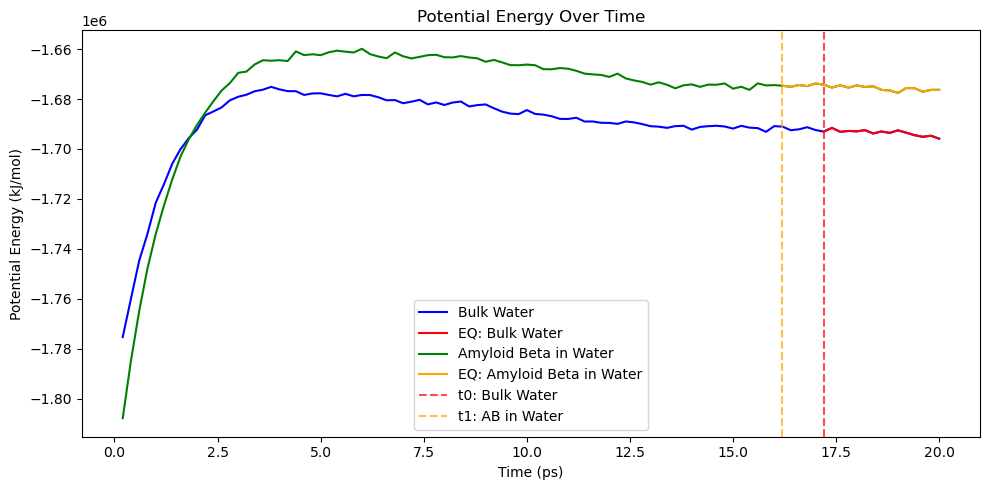

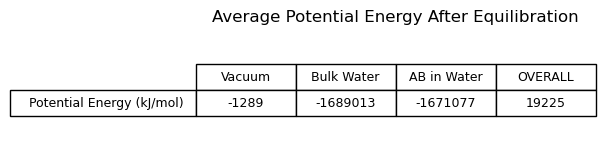

In [176]:
t0, _, _ = detect_equilibration(bulksolvdata[:, 1][10:])
t1, _, _ = detect_equilibration(ABinsolvdata[:, 1][10:])
print(f'The Equilibration time for Bulk Solvent is {t0} ps and for Amyloid Beta in Water is {t1} ps.')
plt.figure(figsize=(10, 5))

plt.plot(step_bulk, bulksolvdata[:, 1], color='blue', label="Bulk Water")
plt.plot(step_bulk[t0:], bulksolvdata[:, 1][t0:], color='red', label="EQ: Bulk Water")

plt.plot(step_AB, ABinsolvdata[:, 1], color='green', label="Amyloid Beta in Water")
plt.plot(step_AB[t1:], ABinsolvdata[:, 1][t1:], color='orange', label="EQ: Amyloid Beta in Water")

plt.axvline(step_bulk[t0], color='red', linestyle='--', alpha=0.7, label='t0: Bulk Water')
plt.axvline(step_AB[t1], color='orange', linestyle='--', alpha=0.7, label='t1: AB in Water')

plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.legend()
plt.title("Potential Energy Over Time")
plt.tight_layout()
plt.show()

t3, _, _ = detect_equilibration(vacuumdata[:, 1])

avgvacuum = np.mean(vacuumdata[:, 1][t3:])
avgbulksolv = np.mean(bulksolvdata[:, 1][t3:])
avgABsolv = np.mean(ABinsolvdata[:, 1][t3:])
overall = avgABsolv - avgbulksolv - avgvacuum

row_labels = ['Potential Energy (kJ/mol)']
col_labels = ['Vacuum', 'Bulk Water', 'AB in Water', 'OVERALL']
table_data = [['{:.0f}'.format(avgvacuum), '{:.0f}'.format(avgbulksolv), '{:.0f}'.format(avgABsolv), '{:.0f}'.format(overall)]]

fig, ax = plt.subplots(figsize=(5, 2))
ax.axis('off')  # Hide axes
table = ax.table(cellText=table_data, colLabels=col_labels, rowLabels=row_labels, cellLoc='center', loc='center')
table.scale(1, 2)
plt.title("Average Potential Energy After Equilibration")
plt.tight_layout(pad=0.1)
plt.subplots_adjust(left=0.1, right=0.9, top=0.8, bottom=0.2)
plt.show()

### Temperature and Volume:

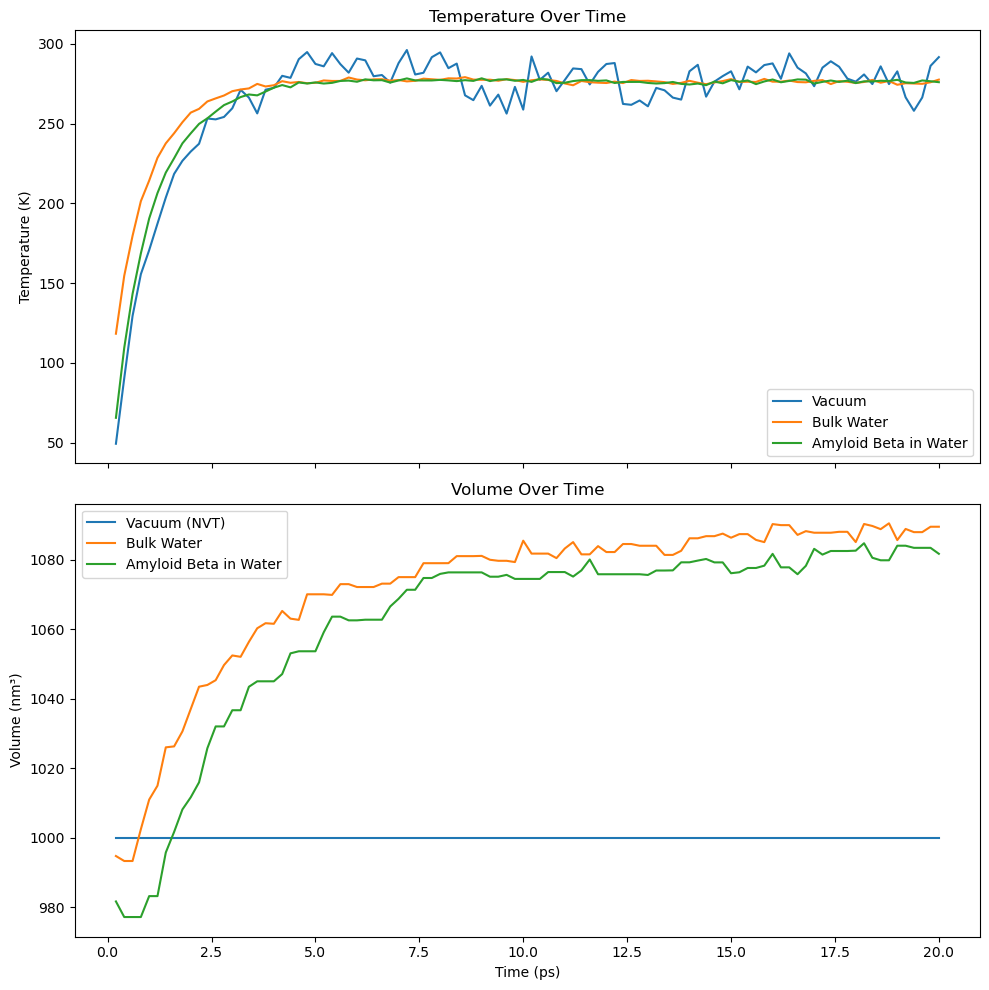

In [177]:
fig, axs = plt.subplots(nrows=2, figsize=(10, 10), sharex=True)

# First subplot: Temperature
axs[0].plot(step_vac, vacuumdata[:, 2], label="Vacuum")
axs[0].plot(step_bulk, bulksolvdata[:, 2], label="Bulk Water")
axs[0].plot(step_AB, ABinsolvdata[:, 2], label="Amyloid Beta in Water")
axs[0].set_ylabel("Temperature (K)")
axs[0].set_title("Temperature Over Time")
axs[0].legend()

# Second subplot: Volume
axs[1].plot(step_vac, vacuumdata[:, 3], label="Vacuum (NVT)")
axs[1].plot(step_bulk, bulksolvdata[:, 3], label="Bulk Water")
axs[1].plot(step_AB, ABinsolvdata[:, 3], label="Amyloid Beta in Water")
axs[1].set_xlabel("Time (ps)")
axs[1].set_ylabel("Volume (nm³)")
axs[1].set_title("Volume Over Time")
axs[1].legend()

plt.tight_layout()
plt.show()

In [180]:
pdblist = ['SavedData/AmyloidBetaVac.pdb', 'SavedData/AmyloidBetainWaterSolvent.pdb']

### Radius of Gyration:

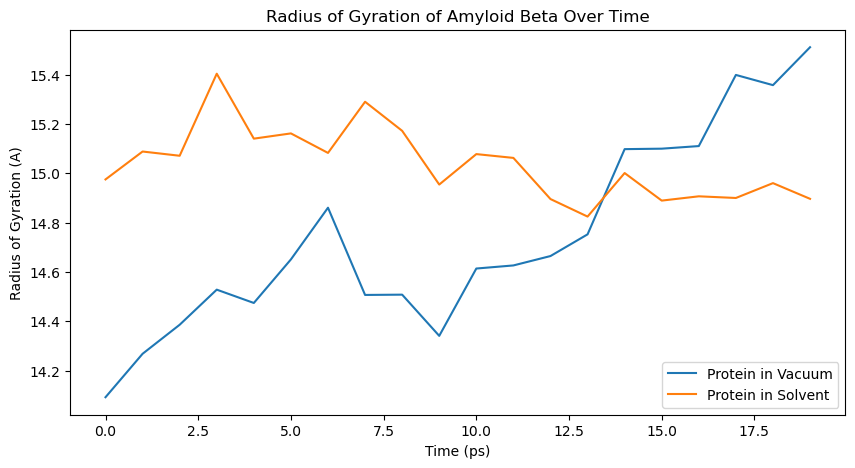

In [181]:
plt.figure(figsize=(10, 5))

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    rgvals = []
    for frame in u.trajectory:
        rgvals.append(protein.radius_of_gyration())
    plt.plot(np.arange(0, 20, 1), rgvals)

plt.xlabel('Time (ps)')
plt.ylabel('Radius of Gyration (A)')
plt.title('Radius of Gyration of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in Solvent'])
plt.show()

### Root Mean Square Deviation:

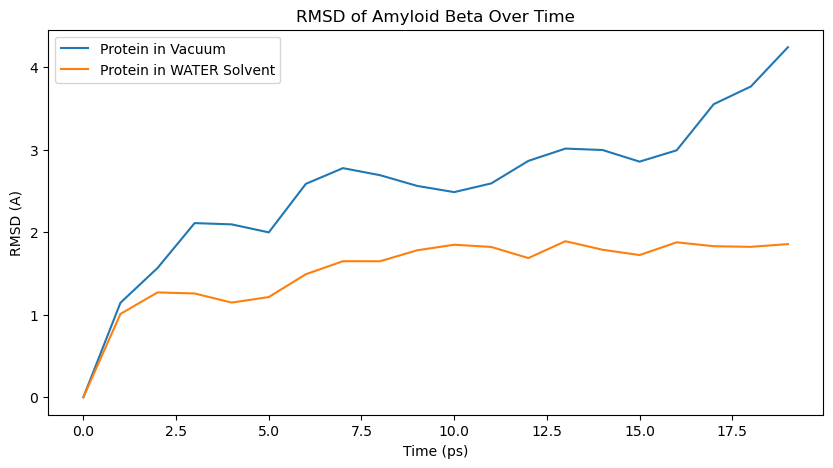

In [124]:
plt.figure(figsize=(10, 5))
from MDAnalysis.analysis.rms import rmsd

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    ref_coords = protein.positions.copy() #Uses the first trajectory as a basis.

    rmsd_vals = []
    for frame in u.trajectory:
        current_coords = protein.positions
        val = rmsd(current_coords, ref_coords, center=True, superposition=True)
        rmsd_vals.append(val)
        
    plt.plot(np.arange(0, 20, 1), rmsd_vals)

plt.xlabel('Time (ps)')
plt.ylabel('RMSD (A)')
plt.title('RMSD of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in WATER Solvent'])
plt.show()

# Simulation in Mannitol:

In [6]:
from openmmforcefields.generators import (GAFFTemplateGenerator)

In OpenMM, we will use a add-on called openmmforcefields to parameterize small molecules.

The GAFFTemplateGenerator is referring to the **Generalized Amber Force Field**. This has parameters for most organic molecules that are made with C,H,N,O,S,P, and halogens.

We use this because it is best compatible with Amber forcefields already used.

## Simulation of Bulk Mannitol:

In [60]:
Mannitol = PDBFile('PDB Files/Packmol/Mannitol/Mannitolx9.pdb')
u = mda.Universe('PDB Files/Packmol/Mannitol/Mannitolx9.pdb')
view = nglview.show_mdanalysis(u)
#AmyloidBetaVacVis.add_ball_and_stick()
view.center()
view.gui_style = None
view

NGLWidget()

In [7]:
from openff.toolkit import Molecule
molecule = Molecule.from_smiles("C([C@H]([C@H]([C@@H]([C@@H](CO)O)O)O)O)O")
gaff = GAFFTemplateGenerator(molecules=molecule)

# Create an OpenMM ForceField object with AMBER ff14SB and TIP3P with compatible ions:
forcefield = ForceField(
    "amber/protein.ff14SB.xml",
    "amber/tip3p_standard.xml",
    "amber/tip3p_HFE_multivalent.xml",
)

# Register the GAFF template generator
forcefield.registerTemplateGenerator(gaff.generator)

# You can now parameterize an OpenMM Topology object that contains the specified molecule.
# forcefield will load the appropriate GAFF parameters when needed, and antechamber
# will be used to generate small molecule parameters on the fly.

Adding a molecule is easy as finding the SMILES string, which is very easy, then just suing GAFFTemplateGenerator to generate a forcefield for the molecule in question. After we incorporate that into the forcefield, we are good to go!.

In [16]:
modeller = Modeller(Mannitol.topology, Mannitol.positions)
modeller.addSolvent(forcefield, padding=1.0*nanometer)

system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=0.3*nanometer, constraints=HBonds)

size = 10.0 * nanometer
system.setDefaultPeriodicBoxVectors(
    Vec3(size, 0, 0),
    Vec3(0, size, 0),
    Vec3(0, 0, size))

integrator = LangevinMiddleIntegrator(275*kelvin, 1/picosecond, 0.002*picoseconds)
simulation = Simulation(modeller.topology, system, integrator, platform)
simulation.context.setPositions(modeller.positions)
simulation.minimizeEnergy()

In [15]:
simulation.reporters.append(PDBReporter('Data/MannitolIW.pdb', 500))
simulation.reporters.append(StateDataReporter(stdout, 500, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))
simulation.reporters.append(StateDataReporter("Data/MannitolIW.txt", 100, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))

In [16]:
system.addForce(MonteCarloBarostat(1*bar, 275*kelvin))
simulation.context.reinitialize(preserveState=True)

print("Running NPT")
simulation.step(10000)

Running NPT
#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)","Density (g/mL)"
500,-658915.1841049287,185.86723465336308,1023.6365335341542,0.45581299945729375
1000,-635022.6718693767,240.6570399936934,1053.0368864443158,0.4430868896527894
1500,-619797.8249937091,259.74870795275706,1101.067872801797,0.42375847141646616
2000,-612674.2637382634,267.1100216461525,1131.417819643395,0.41239127632913747
2500,-605921.6555440277,269.2685149661084,1191.1030156211943,0.3917266874359571
3000,-601089.1150293127,274.64542107852685,1257.7055104821914,0.3709825828189184
3500,-598364.06442759,275.66010599150906,1306.9434082414937,0.35700615325958684
4000,-596385.2182213906,277.1435959332452,1344.858463667332,0.34694122192748883
4500,-595183.8061676361,278.52101679969246,1385.2306980872527,0.33682969872710705
5000,-593941.5956407413,274.9380472945535,1433.5370242223144,0.3254794475625003
5500,-593759.2207335066,278.2140438728862,1476.2663084967048,0.31605871922891676
6000,-5912

In [182]:
u = mda.Universe('SavedData/MannitolIW.pdb')
view = nglview.show_mdanalysis(u, gui=True)
#AmyloidBetaVacVis.add_ball_and_stick()
view.gui_style = None
view.center()
view.parameters = {
    "fogNear": 1,  # Start fog at 100% of the clipping distance
    "fogFar": 0    # Fog is fully opaque at 100% of the clipping distance
}
view

NGLWidget(max_frame=19)

## Simulation of AB with Mannitol Solvent:

In [39]:
ABinMannitol = PDBFile('PDB Files/Packmol/Mannitol/ABinMannitolx9.pdb')
u = mda.Universe('PDB Files/Packmol/Mannitol/ABinMannitolx9.pdb')
view = nglview.show_mdanalysis(u)
#AmyloidBetaVacVis.add_ball_and_stick()
view.center()
view.gui_style = None
view

NGLWidget()

In [41]:
modeller = Modeller(ABinMannitol.topology, ABinMannitol.positions)
modeller.addSolvent(forcefield,padding=1.0*nanometer)

system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=0.3*nanometer, constraints=HBonds)

size = 10.0 * nanometer
system.setDefaultPeriodicBoxVectors(
    Vec3(size, 0, 0),
    Vec3(0, size, 0),
    Vec3(0, 0, size))

integrator = LangevinMiddleIntegrator(275*kelvin, 1/picosecond, 0.004*picoseconds)
simulation = Simulation(modeller.topology, system, integrator, platform)
simulation.context.setPositions(modeller.positions)

simulation.minimizeEnergy()

In [42]:
simulation.reporters.append(PDBReporter('Data/ABInMannitol.pdb', 500))
simulation.reporters.append(StateDataReporter(stdout, 500, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))
simulation.reporters.append(StateDataReporter("Data/ABInMannitol.txt", 100, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))

In [43]:
system.addForce(MonteCarloBarostat(1*bar, 275*kelvin))
simulation.context.reinitialize(preserveState=True)

print("Running NPT")
simulation.step(10000)

Running NPT
#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)","Density (g/mL)"
500,-675146.6046937797,241.55284312367027,1058.9644580706956,0.4739475956417204
1000,-655761.2982768491,266.9536427423831,1093.2760460628183,0.4590731321518458
1500,-647545.4360246547,272.4392733447759,1137.082086373119,0.441387358738104
2000,-643358.7079290543,277.526133892578,1173.3760163467364,0.4277347174141766
2500,-641051.5891954508,277.21723352512424,1209.1429759096332,0.4150821439417214
3000,-640083.1133994665,276.5290100297928,1241.1205854639386,0.40438750646056904
3500,-639807.4704389833,278.673708707836,1290.682945856823,0.38885898383003764
4000,-639825.8363320548,275.28276519753695,1314.1563015431166,0.38191321548533236
4500,-637359.8872062638,276.3007753779378,1370.5186925036828,0.36620708751938086
5000,-632156.8610946108,277.9948549844339,1467.5241552060456,0.3420002709953186
5500,-632546.3004345987,278.961241486312,1519.0392444981253,0.3304020357541612
6000,-631703.005

In [183]:
u = mda.Universe('SavedData/ABInMannitol.pdb')
view = nglview.show_mdanalysis(u, gui=True)
#AmyloidBetaVacVis.add_ball_and_stick()
view.center()
view.gui_style = None
view.parameters = {
    "fogNear": 1,  # Start fog at 100% of the clipping distance
    "fogFar": 0    # Fog is fully opaque at 100% of the clipping distance
}
view

NGLWidget(max_frame=19)

## Comparative Analysis!

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from pymbar.timeseries import detect_equilibration

In [184]:
MannitolIWdata = np.loadtxt("SavedData/MannitolIW.txt", delimiter=',')
ABinMannitoldata = np.loadtxt("SavedData/ABInMannitol.txt", delimiter=',')

step_bulk_mannitol = MannitolIWdata[:, 0] * 0.002
step_AB_mannitol = ABinMannitoldata[:, 0] * 0.002

### Potential Energies

The Equilibration time for Bulk Solvent is 78 ps and for Amyloid Beta in Water is 80 ps.


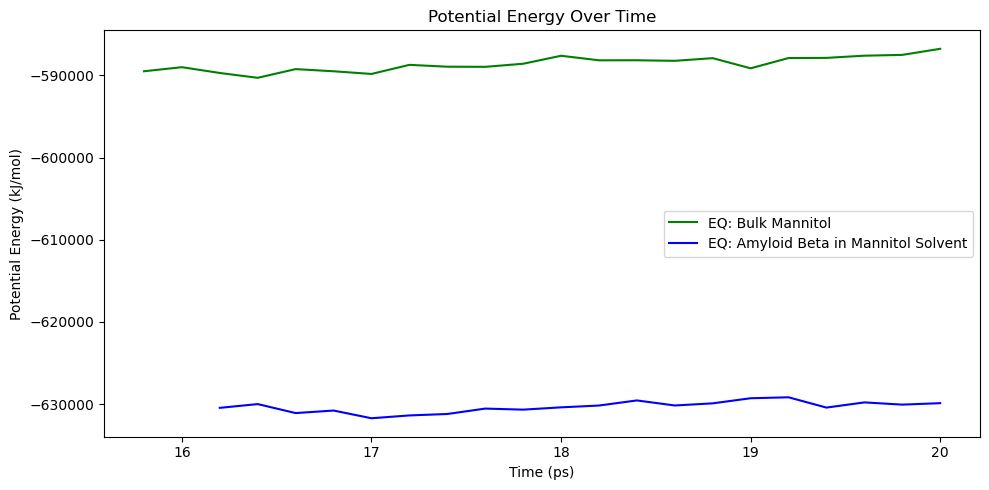

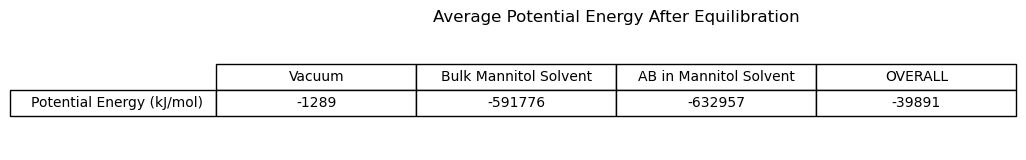

In [40]:
t4, _, _ = detect_equilibration(MannitolIWdata[:, 1][10:])
t5, _, _ = detect_equilibration(ABinMannitoldata[:, 1][10:])
print(f'The Equilibration time for Bulk Solvent is {t4} ps and for Amyloid Beta in Water is {t5} ps.')
plt.figure(figsize=(10, 5))

#plt.plot(step_bulk[t0:], bulksolvdata[:, 1][t0:], color='red', label="EQ: Bulk Water")
#plt.plot(step_AB[t1:], ABinsolvdata[:, 1][t1:], color='orange', label="EQ: Amyloid Beta in Water")
plt.plot(step_bulk_mannitol[t4:], MannitolIWdata[:, 1][t4:], color='green', label="EQ: Bulk Mannitol")
plt.plot(step_AB_mannitol[t5:], ABinMannitoldata[:, 1][t5:], color='blue', label="EQ: Amyloid Beta in Mannitol Solvent")


plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.legend()
plt.title("Potential Energy Over Time")
plt.tight_layout()
plt.show()

avgvacuum = np.mean(vacuumdata[:, 1][t3:])
avgbulkMannitol = np.mean(MannitolIWdata[:, 1][t3:])
avgABMannitol = np.mean(ABinMannitoldata[:, 1][t3:])
overallMannitol = avgABMannitol - avgbulkMannitol - avgvacuum

row_labels = ['Potential Energy (kJ/mol)']
col_labels = ['Vacuum', 'Bulk Mannitol Solvent', 'AB in Mannitol Solvent', 'OVERALL']
table_data = [['{:.0f}'.format(avgvacuum), '{:.0f}'.format(avgbulkMannitol), '{:.0f}'.format(avgABMannitol), '{:.0f}'.format(overallMannitol)]]

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')  # Hide axes
table = ax.table(cellText=table_data, colLabels=col_labels, rowLabels=row_labels, cellLoc='center', loc='center')
table.scale(1, 2)
plt.title("Average Potential Energy After Equilibration")
plt.tight_layout(pad=0.1)
plt.subplots_adjust(left=0.1, right=0.9, top=0.8, bottom=0.2)
plt.show()

### Temp and Volume:

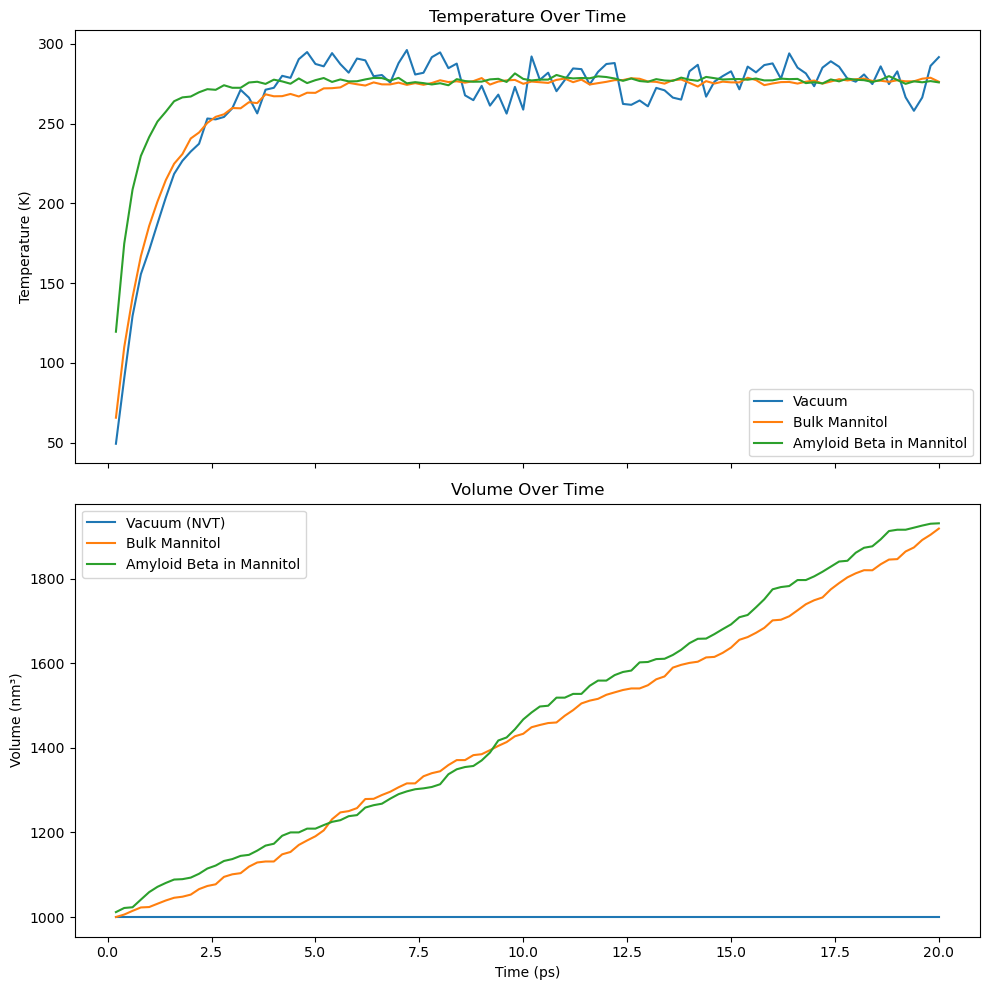

In [41]:
fig, axs = plt.subplots(nrows=2, figsize=(10, 10), sharex=True)

# First subplot: Temperature
axs[0].plot(step_vac, vacuumdata[:, 2], label="Vacuum")
axs[0].plot(step_bulk_mannitol, MannitolIWdata[:, 2], label="Bulk Mannitol")
axs[0].plot(step_AB_mannitol, ABinMannitoldata[:, 2], label="Amyloid Beta in Mannitol")
axs[0].set_ylabel("Temperature (K)")
axs[0].set_title("Temperature Over Time")
axs[0].legend()

# Second subplot: Volume
axs[1].plot(step_vac, vacuumdata[:, 3], label="Vacuum (NVT)")
axs[1].plot(step_bulk_mannitol, MannitolIWdata[:, 3], label="Bulk Mannitol")
axs[1].plot(step_AB_mannitol, ABinMannitoldata[:, 3], label="Amyloid Beta in Mannitol")
axs[1].set_xlabel("Time (ps)")
axs[1].set_ylabel("Volume (nm³)")
axs[1].set_title("Volume Over Time")
axs[1].legend()

plt.tight_layout()
plt.show()

In [185]:
pdblist = ['SavedData/AmyloidBetaVac.pdb', 'SavedData/AmyloidBetainWaterSolvent.pdb', 'SavedData/ABInMannitol.pdb']

### Radius of Gyration:

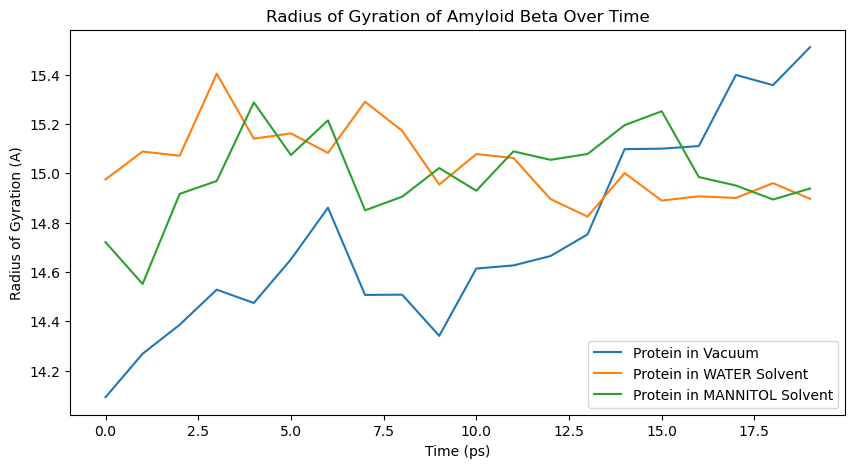

In [186]:
plt.figure(figsize=(10, 5))

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    rgvals = []
    for frame in u.trajectory:
        rgvals.append(protein.radius_of_gyration())
    plt.plot(np.arange(0, 20, 1), rgvals)

plt.xlabel('Time (ps)')
plt.ylabel('Radius of Gyration (A)')
plt.title('Radius of Gyration of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in WATER Solvent', 'Protein in MANNITOL Solvent'])
plt.show()

### Root Mean Square Deviation:

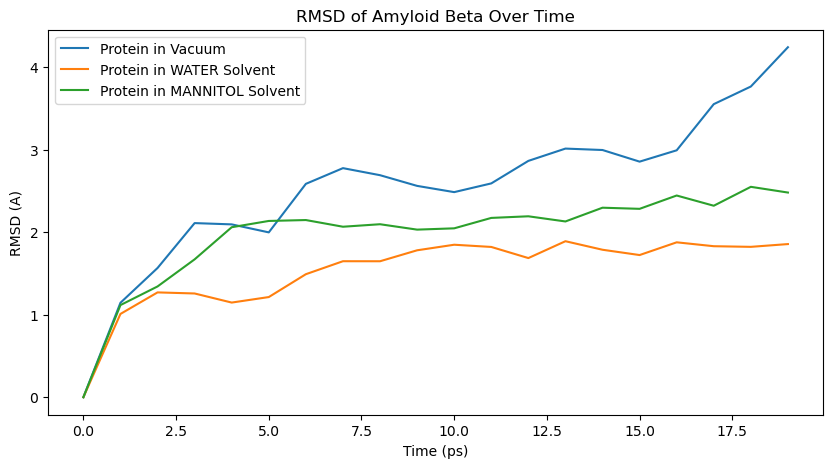

In [79]:
plt.figure(figsize=(10, 5))
from MDAnalysis.analysis.rms import rmsd

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    ref_coords = protein.positions.copy() #Uses the first trajectory as a basis.

    rmsd_vals = []
    for frame in u.trajectory:
        current_coords = protein.positions
        val = rmsd(current_coords, ref_coords, center=True, superposition=True)
        rmsd_vals.append(val)
        
    plt.plot(np.arange(0, 20, 1), rmsd_vals)

plt.xlabel('Time (ps)')
plt.ylabel('RMSD (A)')
plt.title('RMSD of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in WATER Solvent', 'Protein in MANNITOL Solvent'])
plt.show()

# Simulation in Glycerol

## Simulation of Bulk Glycerol:

In [8]:
Glycerol = PDBFile('PDB Files/Packmol/Glycerol/Glycerolx9.pdb')
u = mda.Universe('PDB Files/Packmol/Glycerol/Glycerolx9.pdb')
view = nglview.show_mdanalysis(u)
#AmyloidBetaVacVis.add_ball_and_stick()
view.center()
view.gui_style = None
view

NGLWidget()

In [9]:
from openff.toolkit import Molecule
molecule = Molecule.from_smiles("C(C(CO)O)O")
gaff = GAFFTemplateGenerator(molecules=molecule)

# Create an OpenMM ForceField object with AMBER ff14SB and TIP3P with compatible ions:
forcefield = ForceField(
    "amber/tip3p_HFE_multivalent.xml",
    "amber/protein.ff14SB.xml",
    "amber/tip3p_standard.xml"
)

# Register the GAFF template generator
forcefield.registerTemplateGenerator(gaff.generator)

# You can now parameterize an OpenMM Topology object that contains the specified molecule.
# forcefield will load the appropriate GAFF parameters when needed, and antechamber
# will be used to generate small molecule parameters on the fly.

In [10]:
modeller = Modeller(Glycerol.topology, Glycerol.positions)
modeller.addSolvent(forcefield, padding=1.0*nanometer)

system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=0.3*nanometer, constraints=HBonds)

size = 10.0 * nanometer
system.setDefaultPeriodicBoxVectors(
    Vec3(size, 0, 0),
    Vec3(0, size, 0),
    Vec3(0, 0, size))

integrator = LangevinMiddleIntegrator(275*kelvin, 1/picosecond, 0.002*picoseconds)
simulation = Simulation(modeller.topology, system, integrator, platform)
simulation.context.setPositions(modeller.positions)
simulation.minimizeEnergy()

In [11]:
simulation.reporters.append(PDBReporter('Data/GlycerolIW.pdb', 500))
simulation.reporters.append(StateDataReporter(stdout, 500, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))
simulation.reporters.append(StateDataReporter("Data/GlycerolIW.txt", 100, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))

In [12]:
system.addForce(MonteCarloBarostat(1*bar, 275*kelvin))
simulation.context.reinitialize(preserveState=True)

print("Running NPT")
simulation.step(10000)

Running NPT
#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)","Density (g/mL)"
500,-584386.1277892552,185.55099323362487,1024.234518837183,0.40408355448361655
1000,-562922.9193696398,236.46618588493698,1053.6348717473431,0.3928081122734435
1500,-549567.6050539035,257.2070768134419,1101.6658581048237,0.3756822651366629
2000,-544328.2574982867,267.2874414368498,1132.015804946422,0.3656100234538106
2500,-537474.9718948659,269.2092666150128,1196.5855360263963,0.3458811029681505
3000,-532969.8848218638,275.59469868639616,1263.1880308873956,0.32764427375534544
3500,-529688.5215754937,275.9397309140098,1313.9867580495772,0.31497754635738107
4000,-528193.3391624074,277.979260785715,1351.5598895028224,0.3062212249793769
4500,-527863.6495503262,280.82361255325947,1380.3161364514365,0.299841691382782
5000,-524782.2242834456,276.9493927024573,1438.6234497837704,0.28768912744940484
5500,-524993.4574500546,278.88304671645034,1480.1027374761168,0.2796267546280543
6000,-524715

## Simulation of AB witl Glycerol Solvent:

In [13]:
ABGlycerol = PDBFile('PDB Files/Packmol/Glycerol/ABGlycerol.pdb')
u = mda.Universe('PDB Files/Packmol/Glycerol/ABGlycerol.pdb')
view = nglview.show_mdanalysis(u)
#AmyloidBetaVacVis.add_ball_and_stick()
view.center()
view.gui_style = None
view

NGLWidget()

In [14]:
modeller = Modeller(ABGlycerol.topology, ABGlycerol.positions)
modeller.addSolvent(forcefield, padding=1.0*nanometer)

system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=0.3*nanometer, constraints=HBonds)

size = 10.0 * nanometer
system.setDefaultPeriodicBoxVectors(
    Vec3(size, 0, 0),
    Vec3(0, size, 0),
    Vec3(0, 0, size))

integrator = LangevinMiddleIntegrator(275*kelvin, 1/picosecond, 0.002*picoseconds)
simulation = Simulation(modeller.topology, system, integrator, platform)
simulation.context.setPositions(modeller.positions)
simulation.minimizeEnergy()

In [15]:
simulation.reporters.append(PDBReporter('Data/ABInGlycerol.pdb', 500))
simulation.reporters.append(StateDataReporter(stdout, 500, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))
simulation.reporters.append(StateDataReporter("Data/ABInGlycerol.txt", 100, step=True,
        potentialEnergy=True, temperature=True, volume=True, density =True))

In [16]:
system.addForce(MonteCarloBarostat(1*bar, 275*kelvin))
simulation.context.reinitialize(preserveState=True)

print("Running NPT")
simulation.step(10000)

Running NPT
#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)","Density (g/mL)"
500,-737286.0859184675,187.04323264316875,1046.4761316962536,0.499985736663199
1000,-708665.8029444311,239.6726663981557,1105.8829682832586,0.4731270438307255
1500,-692932.7486107703,259.03148505095334,1175.6868100026627,0.44503615687023074
2000,-682632.68503239,266.51484507439807,1223.811093200931,0.42753586931304355
2500,-676962.6608459279,271.67793190493404,1254.2752129910525,0.4171517815128334
3000,-671344.2736424692,274.9743400024082,1306.8428792338816,0.4003718793749241
3500,-668472.2435047477,275.5777609846334,1367.9740810580547,0.38248030196735966
4000,-664716.3395329844,275.32271094745204,1422.0559099223449,0.367934295660132
4500,-661661.4322921839,275.26295445297893,1492.2196769388374,0.3506341242463403
5000,-661926.331276603,278.4678090723548,1532.0557429129244,0.34151703815410317
5500,-659583.8554672357,277.8929165451806,1594.1734617995069,0.328209666102452
6000,-659075.2

In [187]:
u = mda.Universe('SavedData/ABInGlycerol.pdb')
view = nglview.show_mdanalysis(u)
#AmyloidBetaVacVis.add_ball_and_stick()
view.center()
view.gui_style = None
view

NGLWidget(max_frame=19)

## Comparative Analysis

In [188]:
GlycerolIWdata = np.loadtxt("SavedData/GlycerolIW.txt", delimiter=',')
ABinGlyceroldata = np.loadtxt("SavedData/ABInGlycerol.txt", delimiter=',')

step_bulk_glycerol = GlycerolIWdata[:, 0] * 0.002
step_AB_glycerol = ABinGlyceroldata[:, 0] * 0.002

### Potential Energy:

The Equilibration time for Bulk Solvent is 78 ps and for Amyloid Beta in Water is 80 ps.


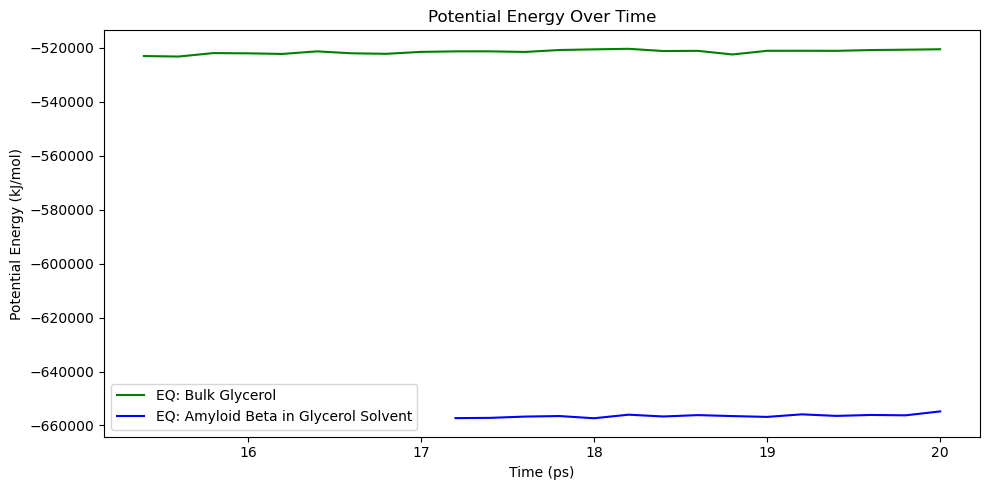

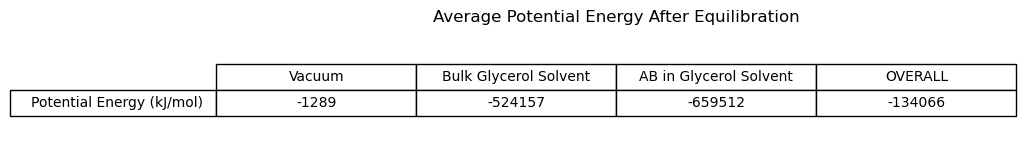

In [47]:
t6, _, _ = detect_equilibration(GlycerolIWdata[:, 1][10:])
t7, _, _ = detect_equilibration(ABinGlyceroldata[:, 1][10:])
print(f'The Equilibration time for Bulk Solvent is {t4} ps and for Amyloid Beta in Water is {t5} ps.')
plt.figure(figsize=(10, 5))

#plt.plot(step_bulk[t0:], bulksolvdata[:, 1][t0:], color='red', label="EQ: Bulk Water")
#plt.plot(step_AB[t1:], ABinsolvdata[:, 1][t1:], color='orange', label="EQ: Amyloid Beta in Water")
plt.plot(step_bulk_glycerol[t6:], GlycerolIWdata[:, 1][t6:], color='green', label="EQ: Bulk Glycerol")
plt.plot(step_AB_glycerol[t7:], ABinGlyceroldata[:, 1][t7:], color='blue', label="EQ: Amyloid Beta in Glycerol Solvent")

plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.legend()
plt.title("Potential Energy Over Time")
plt.tight_layout()
plt.show()

avgvacuum = np.mean(vacuumdata[:, 1][t3:])
avgbulkGlycerol = np.mean(GlycerolIWdata[:, 1][t3:])
avgABGlycerol = np.mean(ABinGlyceroldata[:, 1][t3:])
overallGlycerol = avgABGlycerol - avgbulkGlycerol - avgvacuum

row_labels = ['Potential Energy (kJ/mol)']
col_labels = ['Vacuum', 'Bulk Glycerol Solvent', 'AB in Glycerol Solvent', 'OVERALL']
table_data = [['{:.0f}'.format(avgvacuum), '{:.0f}'.format(avgbulkGlycerol), '{:.0f}'.format(avgABGlycerol), '{:.0f}'.format(overallGlycerol)]]

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=col_labels, rowLabels=row_labels, cellLoc='center', loc='center')
table.scale(1, 2)
plt.title("Average Potential Energy After Equilibration")
plt.tight_layout(pad=0.1)
plt.subplots_adjust(left=0.1, right=0.9, top=0.8, bottom=0.2)
plt.show()

### Temperature and Volume:

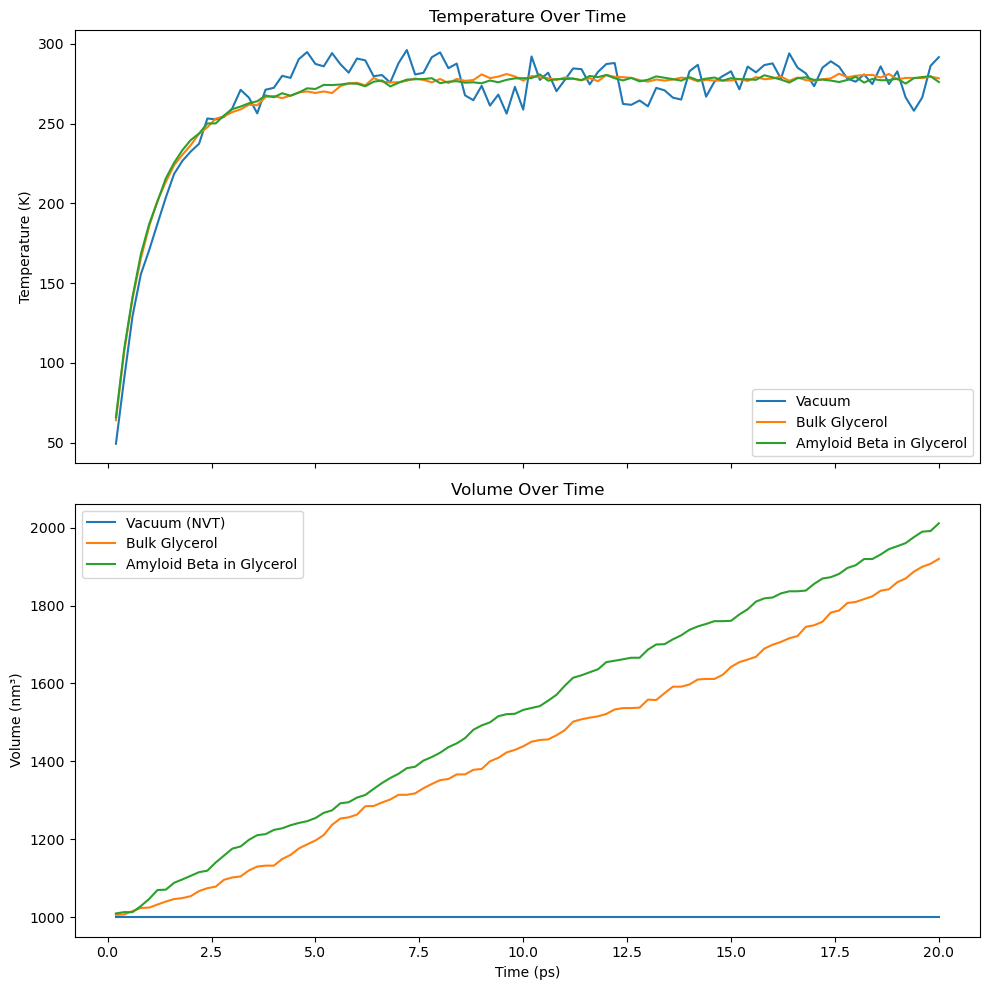

In [50]:
fig, axs = plt.subplots(nrows=2, figsize=(10, 10), sharex=True)

# First subplot: Temperature
axs[0].plot(step_vac, vacuumdata[:, 2], label="Vacuum")
axs[0].plot(step_bulk_glycerol, GlycerolIWdata[:, 2], label="Bulk Glycerol")
axs[0].plot(step_AB_glycerol, ABinGlyceroldata[:, 2], label="Amyloid Beta in Glycerol")
axs[0].set_ylabel("Temperature (K)")
axs[0].set_title("Temperature Over Time")
axs[0].legend()

# Second subplot: Volume
axs[1].plot(step_vac, vacuumdata[:, 3], label="Vacuum (NVT)")
axs[1].plot(step_bulk_glycerol, GlycerolIWdata[:, 3], label="Bulk Glycerol")
axs[1].plot(step_AB_glycerol, ABinGlyceroldata[:, 3], label="Amyloid Beta in Glycerol")
axs[1].set_xlabel("Time (ps)")
axs[1].set_ylabel("Volume (nm³)")
axs[1].set_title("Volume Over Time")
axs[1].legend()

plt.tight_layout()
plt.show()

In [189]:
pdblist = ['SavedData/AmyloidBetaVac.pdb', 'SavedData/AmyloidBetainWaterSolvent.pdb', 'SavedData/ABInGlycerol.pdb']

### Radius of Gyration:

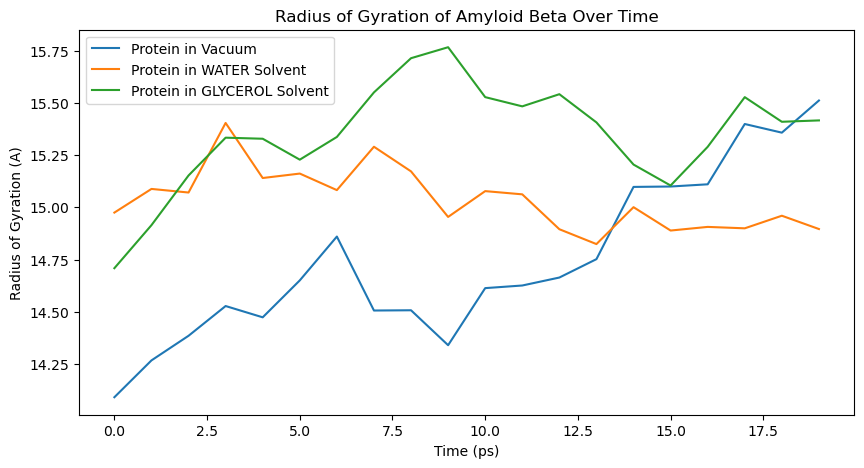

In [157]:
plt.figure(figsize=(10, 5))

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    rgvals = []
    for frame in u.trajectory:
        rgvals.append(protein.radius_of_gyration())
    plt.plot(np.arange(0, 20, 1), rgvals)

plt.xlabel('Time (ps)')
plt.ylabel('Radius of Gyration (A)')
plt.title('Radius of Gyration of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in WATER Solvent', 'Protein in GLYCEROL Solvent'])
plt.show()

### Root Mean Square Deviation:

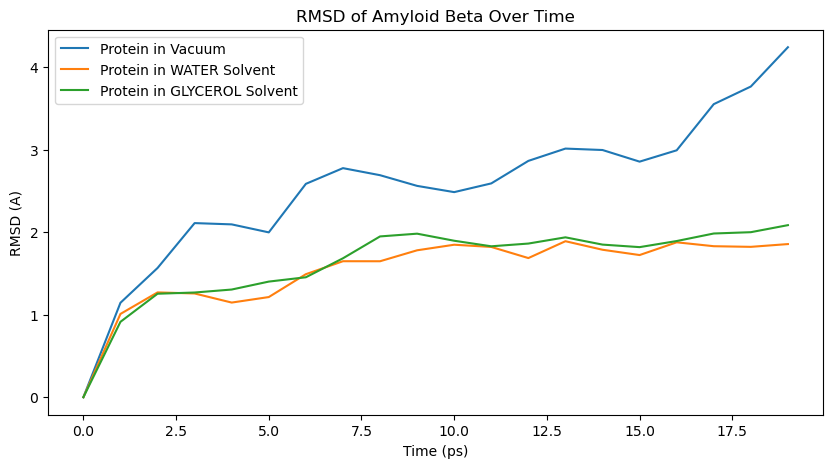

In [129]:
plt.figure(figsize=(10, 5))
from MDAnalysis.analysis.rms import rmsd

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    ref_coords = protein.positions.copy() #Uses the first trajectory as a basis.

    rmsd_vals = []
    for frame in u.trajectory:
        current_coords = protein.positions
        val = rmsd(current_coords, ref_coords, center=True, superposition=True)
        rmsd_vals.append(val)
        
    plt.plot(np.arange(0, 20, 1), rmsd_vals)

plt.xlabel('Time (ps)')
plt.ylabel('RMSD (A)')
plt.title('RMSD of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in WATER Solvent', 'Protein in GLYCEROL Solvent'])
plt.show()

# Overall Comparison:

### Potential Energy Differences in Each Solvent:

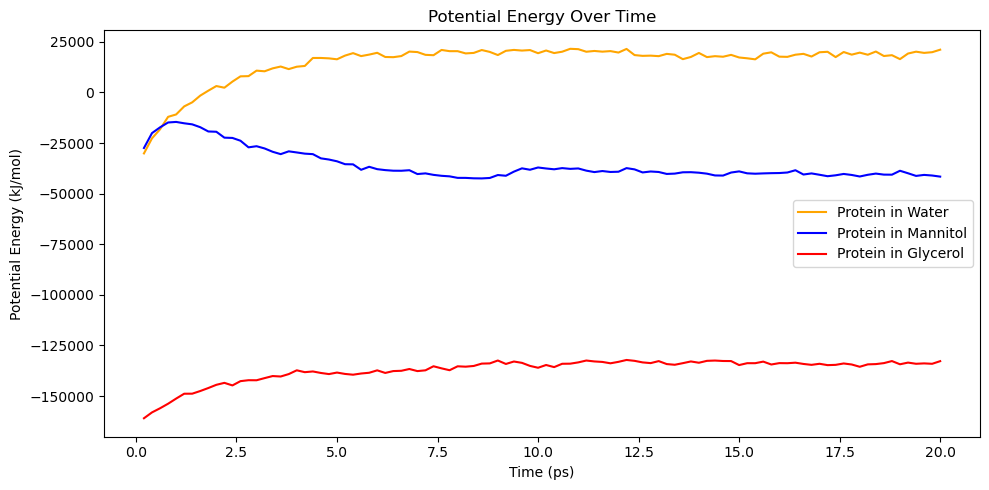

In [190]:
plt.figure(figsize=(10, 5))

water = ABinsolvdata[:, 1] - bulksolvdata[:, 1] -  vacuumdata[:, 1]
mannitol = ABinMannitoldata[:, 1] - MannitolIWdata[:, 1] - vacuumdata[:, 1]
glycerol = ABinGlyceroldata[:, 1] - GlycerolIWdata[:, 1] - vacuumdata[:, 1]

plt.plot(step_AB, water, color='orange', label="EQ: Amyloid Beta in Water Solvent")
plt.plot(step_AB_mannitol, mannitol, color='blue', label="EQ: Amyloid Beta in Mannitol Solvent")
plt.plot(step_AB_glycerol, glycerol, color='red', label="EQ: Amyloid Beta in Glycerol Solvent")

plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.legend(['Protein in Water', 'Protein in Mannitol', 'Protein in Glycerol'])
plt.title("Potential Energy Over Time")
plt.tight_layout()
plt.show()

## Volume Differences in Each Solvent:

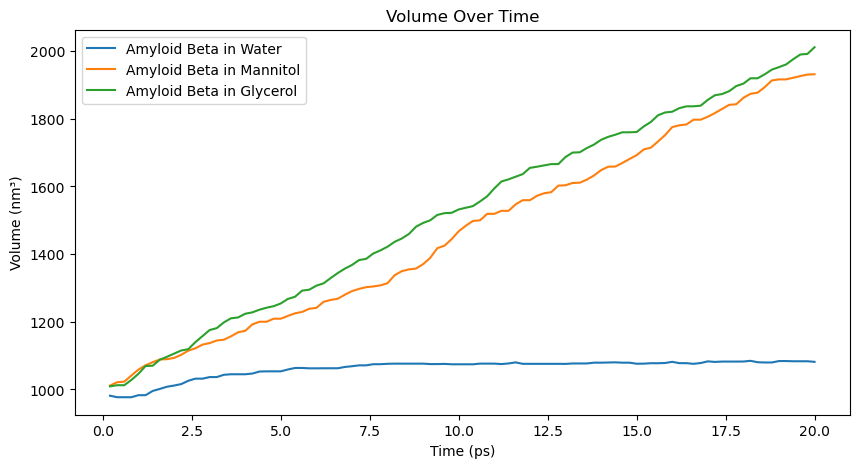

In [149]:
plt.figure(figsize=(10, 5))

plt.plot(step_AB, ABinsolvdata[:, 3], label="Amyloid Beta in Water")
plt.plot(step_AB_mannitol, ABinMannitoldata[:, 3], label="Amyloid Beta in Mannitol")
plt.plot(step_AB_glycerol, ABinGlyceroldata[:, 3], label="Amyloid Beta in Glycerol")
plt.xlabel("Time (ps)")
plt.ylabel("Volume (nm³)")
plt.title("Volume Over Time")
plt.legend()

plt.show()

## R.o.G Differences in Each Solvent:

In [191]:
pdblist = ['SavedData/AmyloidBetaVac.pdb', 'SavedData/AmyloidBetainWaterSolvent.pdb', 'SavedData/ABInMannitol.pdb', 'SavedData/ABInGlycerol.pdb']

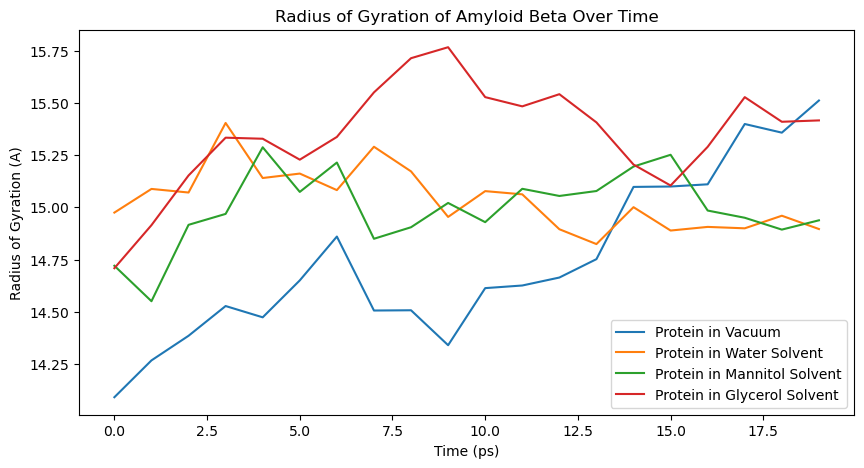

In [192]:
plt.figure(figsize=(10, 5))

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    rgvals = []
    for frame in u.trajectory:
        rgvals.append(protein.radius_of_gyration())
    plt.plot(np.arange(0, 20, 1), rgvals)

plt.xlabel('Time (ps)')
plt.ylabel('Radius of Gyration (A)')
plt.title('Radius of Gyration of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in Water Solvent', 'Protein in Mannitol Solvent', 'Protein in Glycerol Solvent'])
plt.show()

A **LOWER** Radius of Gyration: More Compact (Globular) Protein Structure

A **HIGHER** Radius of Gyration: Extended Protein Structure.

For Amyloid Beta - A High Rg leads to risk of unfolding into local minimized structure, thus increasing the aggregation risk.

## RMSD Differences in Each Solvent:

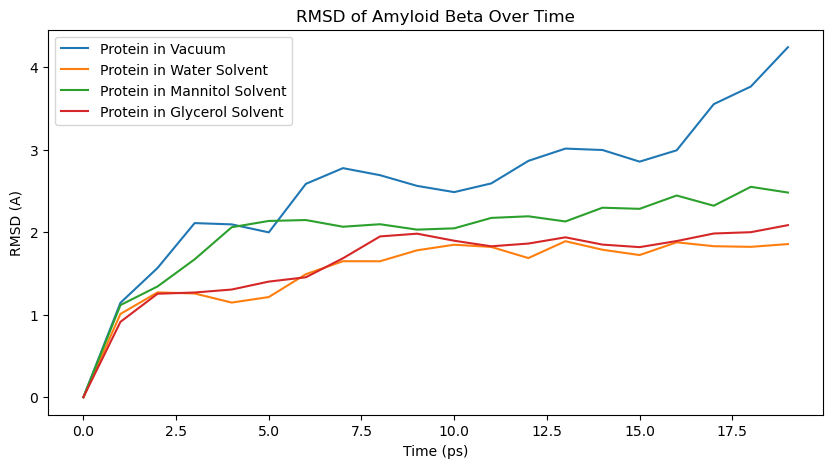

In [193]:
plt.figure(figsize=(10, 5))
from MDAnalysis.analysis.rms import rmsd

for pdb in pdblist:
    u = mda.Universe(pdb)
    protein = u.select_atoms('protein')
    ref_coords = protein.positions.copy() #Uses the first trajectory as a basis.

    rmsd_vals = []
    for frame in u.trajectory:
        current_coords = protein.positions
        val = rmsd(current_coords, ref_coords, center=True, superposition=True)
        rmsd_vals.append(val)
        
    plt.plot(np.arange(0, 20, 1), rmsd_vals)

plt.xlabel('Time (ps)')
plt.ylabel('RMSD (A)')
plt.title('RMSD of Amyloid Beta Over Time')
plt.legend(['Protein in Vacuum', 'Protein in Water Solvent', 'Protein in Mannitol Solvent', 'Protein in Glycerol Solvent'])
plt.show()

RMSD is used to show **how much of a protein's conformation changes over time.** (As we can see at Time=0 the RMSD=0)

A sudden RMSD means a considerable structural change, which can be seen here from 0-5 picoseconds. then slowly increasing.